# Gradient vs Global Centre of Mass (GCM)
Auto-discovers all `gradient_D*_N*.csv` files in the current directory.

The raw per-tick logs read by this notebook (110 files, `gradient_D*_N*.csv`, ~400 MB) are not included in the repository. They can be regenerated with `model/gradient_logging.nlogox` (one file per (D, N) condition). The aggregated statistics are in `data/gradient_summary.csv`. Cell outputs are kept from the original run.

In [1]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load all files

In [2]:
files = sorted(glob.glob("gradient_D*_N*.csv"))
print(f"Found {len(files)} files")

rows = []
for f in files:
    match = re.search(r'gradient_D(\d+)_N(\d+)', f)
    if not match:
        continue
    D, N = int(match.group(1)), int(match.group(2))

    try:
        df = pd.read_csv(f, index_col="tick")
    except Exception as e:
        print(f"  SKIP {f}: {e}")
        continue

    vals = df.values.flatten()
    vals = pd.to_numeric(vals, errors='coerce')
    vals = vals[~np.isnan(vals)]

    if len(vals) == 0:
        print(f"  SKIP {f}: no fleeing data")
        continue

    rows.append({
        'D': D,
        'N': N,
        'ticks': len(df),
        'n_obs': len(vals),
        'mean_abs': np.mean(np.abs(vals)),
        'median_abs': np.median(np.abs(vals)),
        'std': np.std(vals),
        'bias': np.mean(vals),
        'min': np.min(vals),
        'max': np.max(vals),
        'within_correct': 100 * np.mean(np.abs(vals) <= 22.5),  # correct sector
        'within_1adj': 100 * np.mean(np.abs(vals) <= 45),       # ±1 adjacent sector
    })

results = pd.DataFrame(rows).sort_values(['D', 'N']).reset_index(drop=True)
print(f"Loaded {len(results)} conditions")

Found 110 files


Loaded 110 conditions


## 2. Summary table

In [3]:
display_cols = ['D', 'N', 'ticks', 'n_obs', 'mean_abs', 'median_abs', 'std', 'bias', 'within_correct', 'within_1adj']
results[display_cols].style.format({
    'n_obs': '{:,.0f}',
    'mean_abs': '{:.1f}\u00b0',
    'median_abs': '{:.1f}\u00b0',
    'std': '{:.1f}\u00b0',
    'bias': '{:+.1f}\u00b0',
    'within_correct': '{:.1f}%',
    'within_1adj': '{:.1f}%',
})

,D,N,ticks,n_obs,mean_abs,median_abs,std,bias,within_correct,within_1adj
0,1,5,1091,"3,390",51.8°,39.1°,64.4°,-19.7°,29.9%,56.9%
1,1,10,913,"4,824",31.6°,20.1°,48.3°,-5.8°,53.3%,79.4%
2,1,25,1239,"11,282",22.3°,16.2°,32.0°,-3.6°,66.8%,89.1%
3,1,50,2196,"53,587",24.0°,16.4°,35.9°,-0.6°,65.7%,87.0%
4,1,100,1640,"66,765",18.3°,14.7°,24.7°,+1.8°,71.7%,94.3%
5,1,150,9990,"772,408",20.7°,16.0°,27.9°,-0.9°,67.1%,90.0%
6,1,200,9990,"505,335",32.4°,29.9°,39.0°,-0.3°,37.7%,73.1%
7,1,250,9989,"498,871",36.1°,34.1°,42.6°,-2.6°,31.3%,67.3%
8,1,300,9991,"512,017",35.1°,33.5°,41.6°,+0.3°,32.5%,69.1%
9,1,350,9988,"528,012",36.1°,34.6°,42.6°,-0.5°,31.6%,67.0%


In [4]:
results.to_csv("../data/gradient_summary.csv", index=False)
print("Saved to gradient_summary.csv")

Saved to gradient_summary.csv


## 3. Mean |error| by N (one line per D)

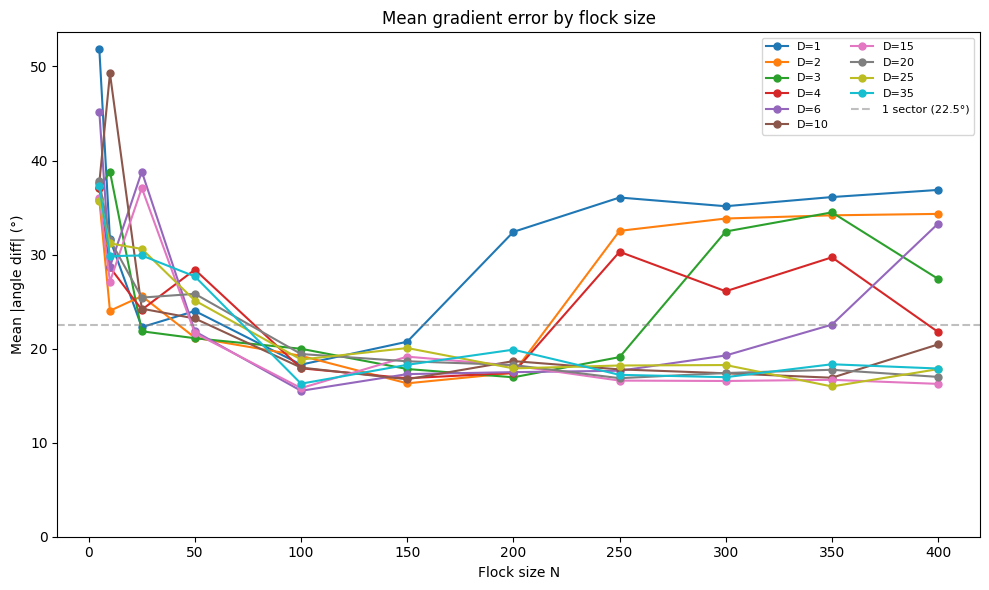

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for d, group in results.groupby('D'):
    group = group.sort_values('N')
    ax.plot(group['N'], group['mean_abs'], 'o-', label=f'D={d}', markersize=5)
ax.axhline(22.5, color='gray', linestyle='--', alpha=0.5, label='1 sector (22.5\u00b0)')
ax.set_xlabel('Flock size N')
ax.set_ylabel('Mean |angle diff| (\u00b0)')
ax.set_title('Mean gradient error by flock size')
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## 4. Heatmap: mean |error| for each (D, N)

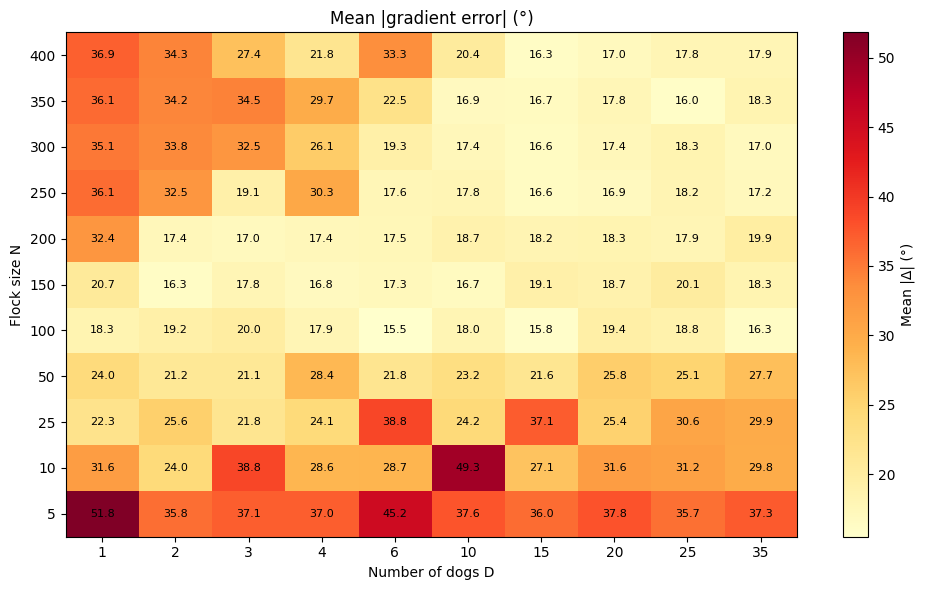

In [6]:
pivot = results.pivot(index='N', columns='D', values='mean_abs')
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Number of dogs D')
ax.set_ylabel('Flock size N')
ax.set_title('Mean |gradient error| (\u00b0)')
# add values in cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Mean |\u0394| (\u00b0)')
plt.tight_layout()
plt.show()

## 5. Aggregation by N

In [7]:
# Weighted aggregation by N (across all D values)
def weighted_agg(group):
    total = group['n_obs'].sum()
    return pd.Series({
        'n_obs_total': total,
        'mean_abs': (group['mean_abs'] * group['n_obs']).sum() / total,
        'median_abs': (group['median_abs'] * group['n_obs']).sum() / total,
        'bias': (group['bias'] * group['n_obs']).sum() / total,
        'within_correct': (group['within_correct'] * group['n_obs']).sum() / total,
        'within_1adj': (group['within_1adj'] * group['n_obs']).sum() / total,
        'n_conditions': len(group),
    })

by_N_all = results.groupby('N').apply(weighted_agg).reset_index()
by_N_all.style.format({
    'n_obs_total': '{:,.0f}',
    'mean_abs': '{:.1f}°',
    'median_abs': '{:.1f}°',
    'bias': '{:+.1f}°',
    'within_correct': '{:.1f}%',
    'within_1adj': '{:.1f}%',
    'n_conditions': '{:.0f}',
})

,N,n_obs_total,mean_abs,median_abs,bias,within_correct,within_1adj,n_conditions
0,5,"68,398",38.1°,22.8°,-7.8°,50.7%,72.3%,10
1,10,"155,496",30.0°,19.1°,-3.8°,60.5%,81.4%,10
2,25,"297,856",27.1°,18.0°,-1.2°,62.7%,83.9%,10
3,50,"690,323",23.8°,16.8°,-0.4°,65.9%,87.8%,10
4,100,"1,179,616",18.2°,14.0°,-0.0°,76.7%,93.5%,10
5,150,"5,821,228",18.3°,14.4°,-0.4°,74.5%,93.4%,10
6,200,"9,080,737",18.5°,14.9°,-0.3°,73.4%,92.8%,10
7,250,"11,825,186",20.5°,17.0°,-0.6°,67.9%,90.0%,10
8,300,"13,442,759",21.0°,17.5°,+0.2°,66.7%,89.2%,10
9,350,"12,464,777",22.2°,18.6°,-0.7°,64.7%,87.3%,10


## Sector-based error distribution


=== Sector error distribution by N (%) ===
  N  mean_sector_err  pct_0  pct_1  pct_2  pct_3  pct_4
  5              0.9   50.5   21.8   16.9    5.8    5.1
 10              0.7   60.2   21.1   11.2    4.5    3.0
 25              0.6   62.5   21.4   10.8    3.4    2.0
 50              0.5   65.6   22.1    8.7    2.2    1.4
100              0.3   76.4   17.0    5.2    1.0    0.4
150              0.3   74.3   19.0    5.7    0.7    0.3
200              0.4   73.2   19.5    6.4    0.6    0.2
250              0.4   67.7   22.2    9.3    0.6    0.2
300              0.5   66.5   22.7   10.2    0.6    0.1
350              0.5   64.5   22.8   11.9    0.7    0.1
400              0.5   66.4   22.4   10.4    0.6    0.1


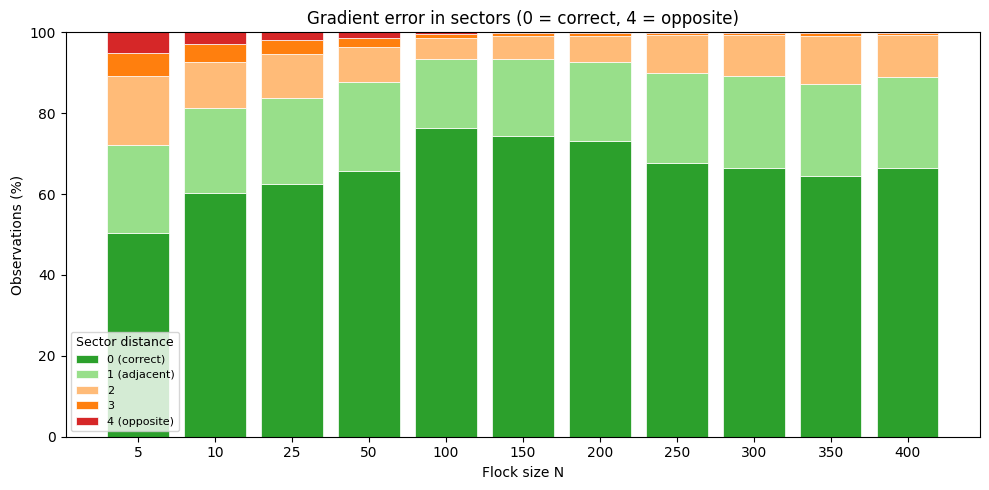


=== Mean sector error by N ===
N=  5: mean=0.93 sectors, correct=50.5%, ±1=72.3%
N= 10: mean=0.69 sectors, correct=60.2%, ±1=81.4%
N= 25: mean=0.61 sectors, correct=62.5%, ±1=83.8%
N= 50: mean=0.52 sectors, correct=65.6%, ±1=87.7%
N=100: mean=0.32 sectors, correct=76.4%, ±1=93.4%
N=150: mean=0.34 sectors, correct=74.3%, ±1=93.3%
N=200: mean=0.35 sectors, correct=73.2%, ±1=92.8%
N=250: mean=0.43 sectors, correct=67.7%, ±1=90.0%
N=300: mean=0.45 sectors, correct=66.5%, ±1=89.1%
N=350: mean=0.49 sectors, correct=64.5%, ±1=87.3%
N=400: mean=0.46 sectors, correct=66.4%, ±1=88.8%


In [9]:

sector_width = 45  # 360° / 8 sectors
bins = [0, 1, 2, 3, 4]  # 0 = correct sector, 4 = opposite direction

sector_rows = []
for f in files:
    match = re.search(r'gradient_D(\d+)_N(\d+)', f)
    if not match:
        continue
    D, N = int(match.group(1)), int(match.group(2))

    try:
        df = pd.read_csv(f, index_col="tick")
    except:
        continue

    vals = df.values.flatten()
    vals = pd.to_numeric(vals, errors='coerce')
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        continue

    # sector distance: round |error| / 45° to nearest int, capped at 4
    abs_vals = np.abs(vals)
    sector_err = np.digitize(abs_vals, bins=[22.5, 45, 90, 135, 180])

    counts = {f'sec_{s}': np.sum(sector_err == s) for s in bins}
    counts['D'] = D
    counts['N'] = N
    counts['n_obs'] = len(vals)
    counts['mean_sector_err'] = np.mean(sector_err)
    sector_rows.append(counts)

sector_df = pd.DataFrame(sector_rows).sort_values(['D', 'N']).reset_index(drop=True)

# Aggregate by N (observation-weighted)
by_N = sector_df.groupby('N').apply(lambda g: pd.Series({
    'n_obs': g['n_obs'].sum(),
    **{f'sec_{s}': g[f'sec_{s}'].sum() for s in bins},
    'mean_sector_err': (g['mean_sector_err'] * g['n_obs']).sum() / g['n_obs'].sum(),
})).reset_index()

for s in bins:
    by_N[f'pct_{s}'] = 100 * by_N[f'sec_{s}'] / by_N['n_obs']

print("=== Sector error distribution by N (%) ===")
print(by_N[['N', 'mean_sector_err'] + [f'pct_{s}' for s in bins]].round(1).to_string(index=False))

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(by_N))
labels = by_N['N'].astype(str)
colors = ['#2ca02c', '#98df8a', '#ffbb78', '#ff7f0e', '#d62728']
names = ['0 (correct)', '1 (adjacent)', '2', '3', '4 (opposite)']

bottom = np.zeros(len(by_N))
for s, color, name in zip(bins, colors, names):
    vals = by_N[f'pct_{s}'].values
    ax.bar(x, vals, bottom=bottom, color=color, label=name, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Flock size N')
ax.set_ylabel('Observations (%)')
ax.set_title('Gradient error in sectors (0 = correct, 4 = opposite)')
ax.legend(title='Sector distance', fontsize=8, title_fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# Print mean sector error
print("\n=== Mean sector error by N ===")
for _, r in by_N.iterrows():
    print(f"N={int(r.N):3d}: mean={r.mean_sector_err:.2f} sectors, "
          f"correct={r.pct_0:.1f}%, ±1={r.pct_0 + r.pct_1:.1f}%")